# Calibration & Subgroup Performance

> **For research and educational purposes only.** This notebook describes how three models
> behaved on their held-out test sets. It is not an audit, and nothing here establishes
> that any model is fair or safe to use.

Reads the artifacts written by

```
python -m scripts.fairness_report
```

Two questions:

1. **Calibration** — when the model says 0.30, do 30% of such people actually have the
   outcome? Measured before and after the calibration wrapper.
2. **Subgroups** — does performance differ by sex or age band, and is any observed gap
   larger than sampling noise *and* large enough to matter?

**The honest answer differs sharply by dataset.** Diabetes has 50,961 test rows and
supports real conclusions. Heart has 61 and kidney 80 — there, the correct output is
"not estimable", and this notebook shows what that looks like rather than hiding it.


In [1]:
import sys, os
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

DISEASES = ["heart", "kidney", "diabetes"]
reports = {d: json.loads(Path(f"reports/{d}/fairness/disparities.json").read_text(encoding="utf-8"))
           for d in DISEASES}
subgroups = {d: pd.read_csv(f"reports/{d}/fairness/subgroups.csv") for d in DISEASES}

pd.DataFrame([{
    "disease": d,
    "test_n": r["test_n"],
    "attributes": ", ".join(r["attributes_analysed"]),
    "reliable_subgroups": f"{r['n_reliable_subgroups']}/{r['n_subgroups']}",
} for d, r in reports.items()])


,disease,test_n,attributes,reliable_subgroups
0,heart,61,"age_band, sex",1/6
1,kidney,80,age_band,0/4
2,diabetes,50961,"age_band, sex",6/6


## 1. Calibration — before and after

Brier mixes calibration with discrimination. **ECE** (expected calibration error) isolates
the calibration part: within each bin of predicted probability, how far is the average
prediction from the observed frequency.

Read them together — ECE alone is blind to ranking, so a model predicting the base rate for
everybody would score a near-perfect ECE while being useless.


In [2]:
rows = []
for d in DISEASES:
    c = json.loads(Path(f"reports/{d}/calibration/summary.json").read_text(encoding="utf-8"))
    rows.append({
        "disease": d, "method": c["method_applied"],
        "brier_before": c["before"]["brier"], "brier_after": c["after"]["brier"],
        "ece_before": c["before"]["ece"], "ece_after": c["after"]["ece"],
        "delta_roc_auc": c["delta_roc_auc"],
    })
display(pd.DataFrame(rows).set_index("disease"))
print("kidney shows no change because 'raw' was selected - the base model was already the")
print("best-calibrated option on training out-of-fold Brier. That is a result, not a bug.")


,method,brier_before,brier_after,ece_before,ece_after,delta_roc_auc
disease,,,,,,
heart,sigmoid,0.100300,0.089331,0.123580,0.076520,0.003247
kidney,raw,0.012681,0.012681,0.036171,0.036171,0.000000
diabetes,isotonic,0.173580,0.095927,0.235611,0.002000,-0.000215


kidney shows no change because 'raw' was selected - the base model was already the
best-calibrated option on training out-of-fold Brier. That is a result, not a bug.


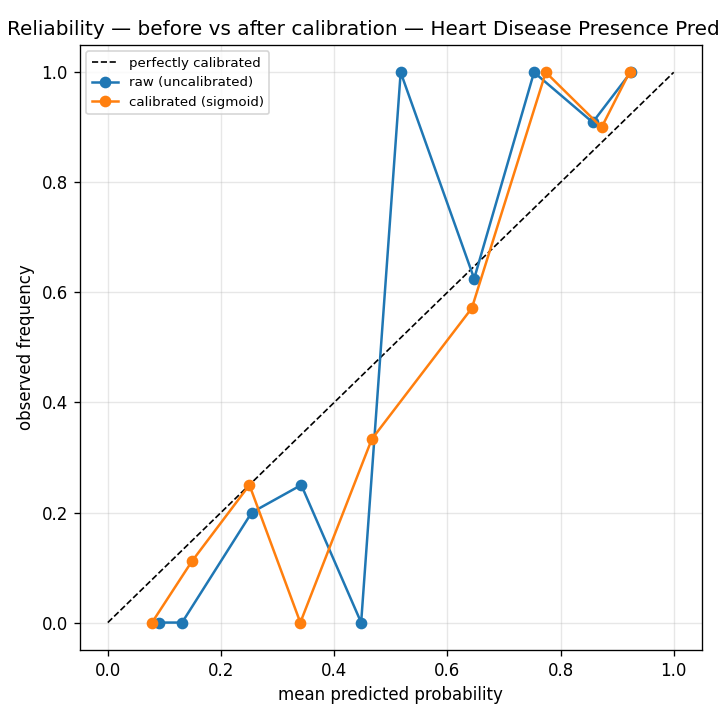

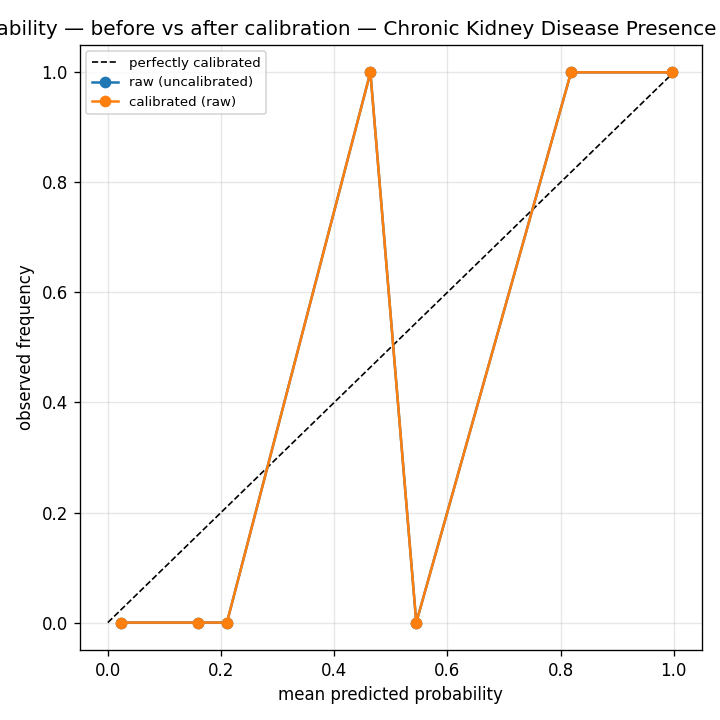

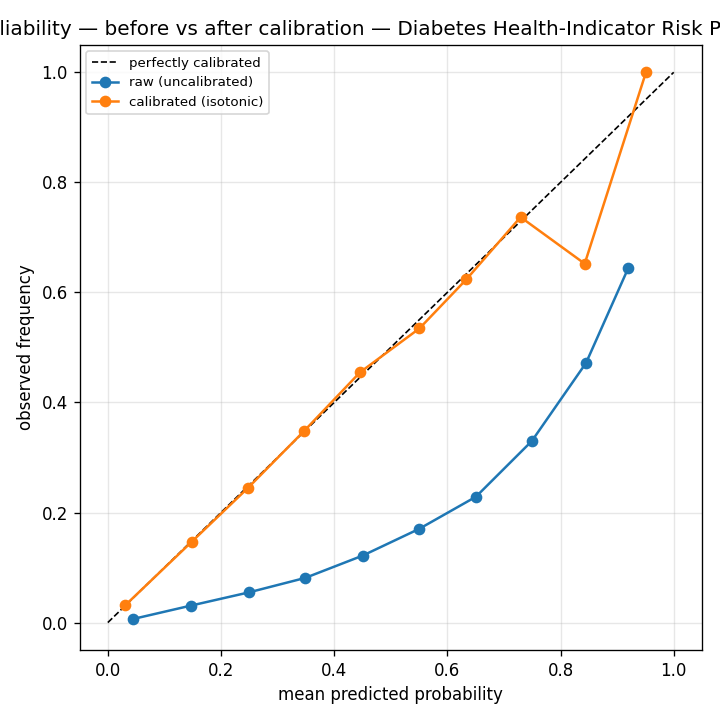

In [3]:
for d in DISEASES:
    png = Path(f"reports/{d}/figures/calibration_before_after.png")
    if png.exists():
        display(Image(filename=str(png)))


## 2. Where subgroup analysis is possible — and where it is not

A subgroup is **reliable** only with at least 20 rows, 10 positives and 10 negatives.
Rates carry Wilson 95% intervals; ROC-AUC carries a Hanley-McNeil interval.


In [4]:
cols = ["attribute", "subgroup", "n", "n_positive", "n_negative",
        "recall", "recall_lo", "recall_hi", "roc_auc", "reliable"]
for d in DISEASES:
    t = subgroups[d]
    t = t[t.threshold_name == "0.5"]
    display(Markdown(f"**{d}** (test n={reports[d]['test_n']})"))
    display(t[cols])


**heart** (test n=61)

,attribute,subgroup,n,n_positive,n_negative,recall,recall_lo,recall_hi,roc_auc,reliable
0,sex,female,20,7,13,0.7143,0.3589,0.9178,0.9890,False
1,sex,male,41,21,20,0.9524,0.7733,0.9915,0.9381,True
4,age_band,45-54,15,4,11,1.0000,0.5101,1.0000,1.0000,False
5,age_band,55-64,27,18,9,0.8333,0.6078,0.9416,0.8889,False
6,age_band,65+,6,3,3,1.0000,0.4385,1.0000,1.0000,False
7,age_band,<45,13,3,10,1.0000,0.4385,1.0000,1.0000,False


**kidney** (test n=80)

,attribute,subgroup,n,n_positive,n_negative,recall,recall_lo,recall_hi,roc_auc,reliable
0,age_band,45-54,12,8,4,1.0000,0.6756,1.0000,1.0000,False
1,age_band,55-64,18,12,6,1.0000,0.7575,1.0000,1.0000,False
2,age_band,65+,25,22,3,1.0000,0.8513,1.0000,1.0000,False
3,age_band,<45,24,7,17,0.7143,0.3589,0.9178,0.9832,False


**diabetes** (test n=50961)

,attribute,subgroup,n,n_positive,n_negative,recall,recall_lo,recall_hi,roc_auc,reliable
0,sex,female,28819,3731,25088,0.1471,0.1361,0.1589,0.8419,True
1,sex,male,22142,3316,18826,0.1457,0.1341,0.1581,0.8179,True
4,age_band,18-34,4848,119,4729,0.0084,0.0015,0.0461,0.8583,True
5,age_band,35-49,10111,645,9466,0.0791,0.0606,0.1025,0.8535,True
6,age_band,50-64,18110,2624,15486,0.1669,0.1531,0.1817,0.8241,True
7,age_band,65+,17892,3659,14233,0.1481,0.1370,0.1600,0.7683,True


### What the heart table shows

Three of heart's age bands report a recall of **1.0000** — with Wilson intervals like
[0.44, 1.00]. Those are not estimates; they are one, three or four patients. The `reliable`
column is what stops them being read as a finding.

Note the trap in both directions: a *small* gap on this table would be equally worthless as
evidence of equity. Too little data to show a disparity is not the same as evidence there
isn't one.


## 3. Disparity verdicts

A gap is a **material difference** only if it clears two bars: the intervals are disjoint
(not noise) *and* the gap is at least 0.05 (large enough to matter). The second bar exists
because with 50,961 rows almost any difference becomes statistically detectable.


In [5]:
rows = []
for d in DISEASES:
    for attr, per_threshold in reports[d]["disparities"].items():
        for tname, per_metric in per_threshold.items():
            for metric, x in per_metric.items():
                if x.get("n_subgroups", 0) < 2:
                    continue
                rows.append({
                    "disease": d, "attribute": attr, "threshold": tname, "metric": metric,
                    "gap": x.get("gap"),
                    "disjoint": x.get("intervals_disjoint"),
                    "reliable": x.get("all_subgroups_reliable"),
                    "material": x.get("conclusive"),
                })
verdicts = pd.DataFrame(rows)
display(verdicts)
print("material differences found:", int(verdicts["material"].sum()))


,disease,attribute,threshold,metric,gap,disjoint,reliable,material
0,heart,sex,0.5,recall,0.2381,False,False,False
1,heart,sex,0.5,specificity,0.2000,False,False,False
2,heart,sex,0.5,precision,0.1667,False,False,False
3,heart,sex,0.5,roc_auc,0.0509,False,False,False
4,heart,sex,operating,recall,0.1428,False,False,False
5,heart,sex,operating,specificity,0.1000,False,False,False
6,heart,sex,operating,precision,0.1000,False,False,False
7,heart,sex,operating,roc_auc,0.0509,False,False,False
8,heart,age_band,0.5,recall,0.1667,False,False,False
9,heart,age_band,0.5,specificity,0.6667,False,False,False


material differences found: 6


## 4. The threshold artifact

Rate metrics are shown at two cut-offs: 0.5 and each model's sensitivity-oriented
threshold. Compare how much the subgroup gaps move.

ROC-AUC is threshold-free and does **not** move. The gap between how far the rate metrics
shift and how far ROC-AUC shifts (zero) measures how much a threshold-based subgroup
comparison is telling you about the cut-off rather than the model.


In [6]:
t = subgroups["diabetes"]
t = t[t.attribute == "age_band"]
display(t.pivot(index="subgroup", columns="threshold_name",
                values=["recall", "specificity", "roc_auc"]).round(4))


recall           specificity           roc_auc          
threshold_name     0.5 operating         0.5 operating     0.5 operating
subgroup                                                                
18-34           0.0084    0.2689      0.9998    0.9852  0.8583    0.8583
35-49           0.0791    0.6109      0.9943    0.8806  0.8535    0.8535
50-64           0.1669    0.7820      0.9808    0.7099  0.8241    0.8241
65+             0.1481    0.8603      0.9720    0.5019  0.7683    0.7683

## 5. Full write-ups

In [7]:
for d in DISEASES:
    display(Markdown(Path(f"reports/{d}/fairness/FAIRNESS.md").read_text(encoding="utf-8")))


# Subgroup performance — Heart Disease Presence Prediction

> **For research and educational purposes only.** This is a description of how one model behaved on one small held-out sample. It is not an audit, and it does not establish that the model is fair or safe to use.

Held-out test set: **n = 61**. Every figure below comes from the shipped pipeline's predictions on those rows; no model was retrained.

## How to read this

A subgroup is marked **reliable** only if it holds at least 20 rows with at least 10 positives and 10 negatives. Rates carry **Wilson 95% intervals**; ROC-AUC carries a Hanley–McNeil interval.

A gap is called a **material difference** only when it clears two separate bars: the intervals must be disjoint (so it is not sampling noise), **and** the gap must be at least 0.05. The second bar matters as much as the first — with 50,961 test rows the intervals become narrow enough that almost any difference separates, so statistical clarity stops implying importance. Small-sample noise and large-sample over-sensitivity are opposite failures and both are named here.

Equal metrics across groups would **not** demonstrate fairness. Only sex and age are available here, the labels carry their own measurement bias, and parity on two attributes says nothing about who a model harms.

**1 of 6 subgroups meet the minimum counts.**

## By sex

### At threshold 0.5

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| female | 20 | 7 | 13 | 0.3500 | 0.7143 | 0.3589 | 0.9178 | 1.0000 | 0.7719 | 1.0000 | 0.9890 | 0.9322 | 1.0000 | False |
| male | 41 | 21 | 20 | 0.5122 | 0.9524 | 0.7733 | 0.9915 | 0.8000 | 0.5840 | 0.9193 | 0.9381 | 0.8604 | 1.0000 | True |

Caveats:

- **female** — only 7 positives (min 10) — recall is not estimable.

Disparity assessment:

- inconclusive — recall: male 0.9524 [0.7733, 0.9915] vs female 0.7143 [0.3589, 0.9178], gap 0.2381. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — specificity: female 1.0000 [0.7719, 1.0000] vs male 0.8000 [0.5840, 0.9193], gap 0.2000. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — precision: female 1.0000 [0.5655, 1.0000] vs male 0.8333 [0.6415, 0.9332], gap 0.1667. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — roc_auc: female 0.9890 [0.9322, 1.0000] vs male 0.9381 [0.8604, 1.0000], gap 0.0509. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.

### At sensitivity-oriented threshold 0.6436

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| female | 20 | 7 | 13 | 0.3500 | 0.7143 | 0.3589 | 0.9178 | 1.0000 | 0.7719 | 1.0000 | 0.9890 | 0.9322 | 1.0000 | False |
| male | 41 | 21 | 20 | 0.5122 | 0.8571 | 0.6536 | 0.9502 | 0.9000 | 0.6990 | 0.9721 | 0.9381 | 0.8604 | 1.0000 | True |

Caveats:

- **female** — only 7 positives (min 10) — recall is not estimable.

Disparity assessment:

- inconclusive — recall: male 0.8571 [0.6536, 0.9502] vs female 0.7143 [0.3589, 0.9178], gap 0.1428. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — specificity: female 1.0000 [0.7719, 1.0000] vs male 0.9000 [0.6990, 0.9721], gap 0.1000. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — precision: female 1.0000 [0.5655, 1.0000] vs male 0.9000 [0.6990, 0.9721], gap 0.1000. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — roc_auc: female 0.9890 [0.9322, 1.0000] vs male 0.9381 [0.8604, 1.0000], gap 0.0509. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.

ROC-AUC is identical across the two threshold blocks above — it does not depend on the cut-off. Only the rate metrics move, and the size of that movement is a direct measure of how much a threshold-based subgroup comparison reflects the threshold rather than the model.

## By age_band

### At threshold 0.5

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 45-54 | 15 | 4 | 11 | 0.2667 | 1.0000 | 0.5101 | 1.0000 | 1.0000 | 0.7412 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| 55-64 | 27 | 18 | 9 | 0.6667 | 0.8333 | 0.6078 | 0.9416 | 0.7778 | 0.4526 | 0.9368 | 0.8889 | 0.7658 | 1.0000 | False |
| 65+ | 6 | 3 | 3 | 0.5000 | 1.0000 | 0.4385 | 1.0000 | 0.3333 | 0.0615 | 0.7923 | 1.0000 | 1.0000 | 1.0000 | False |
| <45 | 13 | 3 | 10 | 0.2308 | 1.0000 | 0.4385 | 1.0000 | 1.0000 | 0.7225 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |

Caveats:

- **45-54** — only 15 rows (min 20); only 4 positives (min 10) — recall is not estimable.
- **55-64** — only 9 negatives (min 10) — specificity is not estimable.
- **65+** — only 6 rows (min 20); only 3 positives (min 10) — recall is not estimable; only 3 negatives (min 10) — specificity is not estimable.
- **<45** — only 13 rows (min 20); only 3 positives (min 10) — recall is not estimable.

Disparity assessment:

- inconclusive — recall: 45-54 1.0000 [0.5101, 1.0000] vs 55-64 0.8333 [0.6078, 0.9416], gap 0.1667. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — specificity: 45-54 1.0000 [0.7412, 1.0000] vs 65+ 0.3333 [0.0615, 0.7923], gap 0.6667. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — precision: 45-54 1.0000 [0.5101, 1.0000] vs 65+ 0.6000 [0.2307, 0.8824], gap 0.4000. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — roc_auc: 45-54 1.0000 [1.0000, 1.0000] vs 55-64 0.8889 [0.7658, 1.0000], gap 0.1111. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.

### At sensitivity-oriented threshold 0.6436

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 45-54 | 15 | 4 | 11 | 0.2667 | 1.0000 | 0.5101 | 1.0000 | 1.0000 | 0.7412 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| 55-64 | 27 | 18 | 9 | 0.6667 | 0.7778 | 0.5479 | 0.9100 | 0.7778 | 0.4526 | 0.9368 | 0.8889 | 0.7658 | 1.0000 | False |
| 65+ | 6 | 3 | 3 | 0.5000 | 1.0000 | 0.4385 | 1.0000 | 1.0000 | 0.4385 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| <45 | 13 | 3 | 10 | 0.2308 | 0.6667 | 0.2077 | 0.9385 | 1.0000 | 0.7225 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |

Caveats:

- **45-54** — only 15 rows (min 20); only 4 positives (min 10) — recall is not estimable.
- **55-64** — only 9 negatives (min 10) — specificity is not estimable.
- **65+** — only 6 rows (min 20); only 3 positives (min 10) — recall is not estimable; only 3 negatives (min 10) — specificity is not estimable.
- **<45** — only 13 rows (min 20); only 3 positives (min 10) — recall is not estimable.

Disparity assessment:

- inconclusive — recall: 45-54 1.0000 [0.5101, 1.0000] vs <45 0.6667 [0.2077, 0.9385], gap 0.3333. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — specificity: 45-54 1.0000 [0.7412, 1.0000] vs 55-64 0.7778 [0.4526, 0.9368], gap 0.2222. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — precision: 45-54 1.0000 [0.5101, 1.0000] vs 55-64 0.8750 [0.6398, 0.9650], gap 0.1250. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — roc_auc: 45-54 1.0000 [1.0000, 1.0000] vs 55-64 0.8889 [0.7658, 1.0000], gap 0.1111. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.

ROC-AUC is identical across the two threshold blocks above — it does not depend on the cut-off. Only the rate metrics move, and the size of that movement is a direct measure of how much a threshold-based subgroup comparison reflects the threshold rather than the model.

One caveat specific to age: age is itself one of the model's strongest features, so computing ROC-AUC *within* an age band removes most of the variance in that feature. Within-band AUC is therefore not directly comparable to the overall test AUC. Comparing bands against each other remains meaningful, but the bands span different widths of the underlying age range, so some of the difference between them reflects that rather than model behaviour.

## Calibration

Wrapper applied: `sigmoid`

| | Brier | ECE | ROC-AUC |
|---|---|---|---|
| before (raw) | 0.100300 | 0.123580 | 0.9502 |
| after | 0.089331 | 0.076520 | 0.9535 |
| delta | -0.010969 | -0.047059 | +0.0032 |

ECE is the population-weighted mean gap between predicted probability and observed frequency across 10 bins. It isolates calibration, where Brier mixes calibration with discrimination — but ECE alone is blind to ranking, so a model predicting the base rate for everyone would score near-perfectly. Read the two together.

_Brier and ECE are computed on the held-out test set for reporting. The calibration method itself was chosen on training out-of-fold Brier alone; these figures played no part in that choice._

See `figures/calibration_before_after.png` for the reliability curves.

---
*Generated by `scripts/fairness_report.py`. Every number above comes from that run.*


# Subgroup performance — Chronic Kidney Disease Presence Prediction

> **For research and educational purposes only.** This is a description of how one model behaved on one small held-out sample. It is not an audit, and it does not establish that the model is fair or safe to use.

Held-out test set: **n = 80**. Every figure below comes from the shipped pipeline's predictions on those rows; no model was retrained.

## How to read this

A subgroup is marked **reliable** only if it holds at least 20 rows with at least 10 positives and 10 negatives. Rates carry **Wilson 95% intervals**; ROC-AUC carries a Hanley–McNeil interval.

A gap is called a **material difference** only when it clears two separate bars: the intervals must be disjoint (so it is not sampling noise), **and** the gap must be at least 0.05. The second bar matters as much as the first — with 50,961 test rows the intervals become narrow enough that almost any difference separates, so statistical clarity stops implying importance. Small-sample noise and large-sample over-sensitivity are opposite failures and both are named here.

Equal metrics across groups would **not** demonstrate fairness. Only sex and age are available here, the labels carry their own measurement bias, and parity on two attributes says nothing about who a model harms.

### Attributes that could not be analysed

- **sex** — not recorded in this dataset — no sex breakdown is possible, and its absence cannot be worked around without inventing data.

**0 of 4 subgroups meet the minimum counts.**

## By age_band

### At threshold 0.5

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 45-54 | 12 | 8 | 4 | 0.6667 | 1.0000 | 0.6756 | 1.0000 | 1.0000 | 0.5101 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| 55-64 | 18 | 12 | 6 | 0.6667 | 1.0000 | 0.7575 | 1.0000 | 1.0000 | 0.6097 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| 65+ | 25 | 22 | 3 | 0.8800 | 1.0000 | 0.8513 | 1.0000 | 1.0000 | 0.4385 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| <45 | 24 | 7 | 17 | 0.2917 | 0.7143 | 0.3589 | 0.9178 | 0.9412 | 0.7302 | 0.9895 | 0.9832 | 0.9138 | 1.0000 | False |

Caveats:

- **45-54** — only 12 rows (min 20); only 8 positives (min 10) — recall is not estimable; only 4 negatives (min 10) — specificity is not estimable.
- **55-64** — only 18 rows (min 20); only 6 negatives (min 10) — specificity is not estimable.
- **65+** — only 3 negatives (min 10) — specificity is not estimable.
- **<45** — only 7 positives (min 10) — recall is not estimable.

Disparity assessment:

- inconclusive — recall: 45-54 1.0000 [0.6756, 1.0000] vs <45 0.7143 [0.3589, 0.9178], gap 0.2857. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — specificity: 45-54 1.0000 [0.5101, 1.0000] vs <45 0.9412 [0.7302, 0.9895], gap 0.0588. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — precision: 45-54 1.0000 [0.6756, 1.0000] vs <45 0.8333 [0.4365, 0.9699], gap 0.1667. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — roc_auc: 45-54 1.0000 [1.0000, 1.0000] vs <45 0.9832 [0.9138, 1.0000], gap 0.0168. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.

### At sensitivity-oriented threshold 0.5792

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 45-54 | 12 | 8 | 4 | 0.6667 | 1.0000 | 0.6756 | 1.0000 | 1.0000 | 0.5101 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| 55-64 | 18 | 12 | 6 | 0.6667 | 1.0000 | 0.7575 | 1.0000 | 1.0000 | 0.6097 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| 65+ | 25 | 22 | 3 | 0.8800 | 1.0000 | 0.8513 | 1.0000 | 1.0000 | 0.4385 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | False |
| <45 | 24 | 7 | 17 | 0.2917 | 0.7143 | 0.3589 | 0.9178 | 1.0000 | 0.8157 | 1.0000 | 0.9832 | 0.9138 | 1.0000 | False |

Caveats:

- **45-54** — only 12 rows (min 20); only 8 positives (min 10) — recall is not estimable; only 4 negatives (min 10) — specificity is not estimable.
- **55-64** — only 18 rows (min 20); only 6 negatives (min 10) — specificity is not estimable.
- **65+** — only 3 negatives (min 10) — specificity is not estimable.
- **<45** — only 7 positives (min 10) — recall is not estimable.

Disparity assessment:

- inconclusive — recall: 45-54 1.0000 [0.6756, 1.0000] vs <45 0.7143 [0.3589, 0.9178], gap 0.2857. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — specificity: 45-54 1.0000 [0.5101, 1.0000] vs 45-54 1.0000 [0.5101, 1.0000], gap 0.0000. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — precision: 45-54 1.0000 [0.6756, 1.0000] vs 45-54 1.0000 [0.6756, 1.0000], gap 0.0000. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.
- inconclusive — roc_auc: 45-54 1.0000 [1.0000, 1.0000] vs <45 0.9832 [0.9138, 1.0000], gap 0.0168. At least one of these subgroups is below the minimum class counts, so this gap is NOT evidence of a disparity — and the absence of a gap would not be evidence of equity either. The test set is too small to support any claim about these groups.

ROC-AUC is identical across the two threshold blocks above — it does not depend on the cut-off. Only the rate metrics move, and the size of that movement is a direct measure of how much a threshold-based subgroup comparison reflects the threshold rather than the model.

One caveat specific to age: age is itself one of the model's strongest features, so computing ROC-AUC *within* an age band removes most of the variance in that feature. Within-band AUC is therefore not directly comparable to the overall test AUC. Comparing bands against each other remains meaningful, but the bands span different widths of the underlying age range, so some of the difference between them reflects that rather than model behaviour.

## Calibration

Wrapper applied: `raw` — the base model was already the best-calibrated option on training out-of-fold Brier, so the before/after columns are identical by construction

| | Brier | ECE | ROC-AUC |
|---|---|---|---|
| before (raw) | 0.012681 | 0.036171 | 0.9987 |
| after | 0.012681 | 0.036171 | 0.9987 |
| delta | +0.000000 | +0.000000 | +0.0000 |

ECE is the population-weighted mean gap between predicted probability and observed frequency across 10 bins. It isolates calibration, where Brier mixes calibration with discrimination — but ECE alone is blind to ranking, so a model predicting the base rate for everyone would score near-perfectly. Read the two together.

_Brier and ECE are computed on the held-out test set for reporting. The calibration method itself was chosen on training out-of-fold Brier alone; these figures played no part in that choice._

See `figures/calibration_before_after.png` for the reliability curves.

---
*Generated by `scripts/fairness_report.py`. Every number above comes from that run.*


# Subgroup performance — Diabetes Health-Indicator Risk Prediction

> **For research and educational purposes only.** This is a description of how one model behaved on one small held-out sample. It is not an audit, and it does not establish that the model is fair or safe to use.

Held-out test set: **n = 50961**. Every figure below comes from the shipped pipeline's predictions on those rows; no model was retrained.

## How to read this

A subgroup is marked **reliable** only if it holds at least 20 rows with at least 10 positives and 10 negatives. Rates carry **Wilson 95% intervals**; ROC-AUC carries a Hanley–McNeil interval.

A gap is called a **material difference** only when it clears two separate bars: the intervals must be disjoint (so it is not sampling noise), **and** the gap must be at least 0.05. The second bar matters as much as the first — with 50,961 test rows the intervals become narrow enough that almost any difference separates, so statistical clarity stops implying importance. Small-sample noise and large-sample over-sensitivity are opposite failures and both are named here.

Equal metrics across groups would **not** demonstrate fairness. Only sex and age are available here, the labels carry their own measurement bias, and parity on two attributes says nothing about who a model harms.

**6 of 6 subgroups meet the minimum counts.**

## By sex

### At threshold 0.5

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| female | 28819 | 3731 | 25088 | 0.1295 | 0.1471 | 0.1361 | 0.1589 | 0.9841 | 0.9825 | 0.9856 | 0.8419 | 0.8338 | 0.8499 | True |
| male | 22142 | 3316 | 18826 | 0.1498 | 0.1457 | 0.1341 | 0.1581 | 0.9814 | 0.9793 | 0.9832 | 0.8179 | 0.8088 | 0.8270 | True |

Disparity assessment:

- inconclusive — recall: female 0.1471 [0.1361, 0.1589] vs male 0.1457 [0.1341, 0.1581], gap 0.0014. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- inconclusive — specificity: female 0.9841 [0.9825, 0.9856] vs male 0.9814 [0.9793, 0.9832], gap 0.0027. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- inconclusive — precision: female 0.5791 [0.5474, 0.6102] vs female 0.5791 [0.5474, 0.6102], gap 0.0000. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- small but statistically clear — roc_auc: female 0.8419 [0.8338, 0.8499] vs male 0.8179 [0.8088, 0.8270], gap 0.0240. The intervals are disjoint, so the difference is statistically clear — but it is smaller than 0.05, and at this sample size confidence intervals are narrow enough that almost any difference separates. Report it as a measured but small difference, not as a disparity worth acting on.

### At sensitivity-oriented threshold 0.1388

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| female | 28819 | 3731 | 25088 | 0.1295 | 0.7899 | 0.7765 | 0.8026 | 0.7384 | 0.7329 | 0.7438 | 0.8419 | 0.8338 | 0.8499 | True |
| male | 22142 | 3316 | 18826 | 0.1498 | 0.8079 | 0.7941 | 0.8210 | 0.6697 | 0.6630 | 0.6764 | 0.8179 | 0.8088 | 0.8270 | True |

Disparity assessment:

- inconclusive — recall: male 0.8079 [0.7941, 0.8210] vs female 0.7899 [0.7765, 0.8026], gap 0.0180. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- **MATERIAL DIFFERENCE** — specificity: female 0.7384 [0.7329, 0.7438] vs male 0.6697 [0.6630, 0.6764], gap 0.0687. The intervals are disjoint and the gap exceeds the practical threshold of 0.05, so this is a real and material difference in how the model performs across these groups. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- inconclusive — precision: female 0.3099 [0.3007, 0.3193] vs male 0.3011 [0.2917, 0.3107], gap 0.0088. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- small but statistically clear — roc_auc: female 0.8419 [0.8338, 0.8499] vs male 0.8179 [0.8088, 0.8270], gap 0.0240. The intervals are disjoint, so the difference is statistically clear — but it is smaller than 0.05, and at this sample size confidence intervals are narrow enough that almost any difference separates. Report it as a measured but small difference, not as a disparity worth acting on.

ROC-AUC is identical across the two threshold blocks above — it does not depend on the cut-off. Only the rate metrics move, and the size of that movement is a direct measure of how much a threshold-based subgroup comparison reflects the threshold rather than the model.

## By age_band

### At threshold 0.5

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 18-34 | 4848 | 119 | 4729 | 0.0245 | 0.0084 | 0.0015 | 0.0461 | 0.9998 | 0.9988 | 1.0000 | 0.8583 | 0.8156 | 0.9010 | True |
| 35-49 | 10111 | 645 | 9466 | 0.0638 | 0.0791 | 0.0606 | 0.1025 | 0.9943 | 0.9926 | 0.9956 | 0.8535 | 0.8348 | 0.8722 | True |
| 50-64 | 18110 | 2624 | 15486 | 0.1449 | 0.1669 | 0.1531 | 0.1817 | 0.9808 | 0.9785 | 0.9829 | 0.8241 | 0.8140 | 0.8341 | True |
| 65+ | 17892 | 3659 | 14233 | 0.2045 | 0.1481 | 0.1370 | 0.1600 | 0.9720 | 0.9692 | 0.9746 | 0.7683 | 0.7588 | 0.7778 | True |

Disparity assessment:

- **MATERIAL DIFFERENCE** — recall: 50-64 0.1669 [0.1531, 0.1817] vs 18-34 0.0084 [0.0015, 0.0461], gap 0.1585. The intervals are disjoint and the gap exceeds the practical threshold of 0.05, so this is a real and material difference in how the model performs across these groups. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- small but statistically clear — specificity: 18-34 0.9998 [0.9988, 1.0000] vs 65+ 0.9720 [0.9692, 0.9746], gap 0.0278. The intervals are disjoint, so the difference is statistically clear — but it is smaller than 0.05, and at this sample size confidence intervals are narrow enough that almost any difference separates. Report it as a measured but small difference, not as a disparity worth acting on. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- inconclusive — precision: 50-64 0.5959 [0.5600, 0.6308] vs 35-49 0.4857 [0.3923, 0.5801], gap 0.1102. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- **MATERIAL DIFFERENCE** — roc_auc: 18-34 0.8583 [0.8156, 0.9010] vs 65+ 0.7683 [0.7588, 0.7778], gap 0.0900. The intervals are disjoint and the gap exceeds the practical threshold of 0.05, so this is a real and material difference in how the model performs across these groups.

### At sensitivity-oriented threshold 0.1388

| subgroup | n | n_positive | n_negative | prevalence | recall | recall_lo | recall_hi | specificity | specificity_lo | specificity_hi | roc_auc | roc_auc_lo | roc_auc_hi | reliable |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 18-34 | 4848 | 119 | 4729 | 0.0245 | 0.2689 | 0.1974 | 0.3549 | 0.9852 | 0.9813 | 0.9883 | 0.8583 | 0.8156 | 0.9010 | True |
| 35-49 | 10111 | 645 | 9466 | 0.0638 | 0.6109 | 0.5727 | 0.6477 | 0.8806 | 0.8739 | 0.8870 | 0.8535 | 0.8348 | 0.8722 | True |
| 50-64 | 18110 | 2624 | 15486 | 0.1449 | 0.7820 | 0.7658 | 0.7974 | 0.7099 | 0.7027 | 0.7170 | 0.8241 | 0.8140 | 0.8341 | True |
| 65+ | 17892 | 3659 | 14233 | 0.2045 | 0.8603 | 0.8487 | 0.8712 | 0.5019 | 0.4937 | 0.5101 | 0.7683 | 0.7588 | 0.7778 | True |

Disparity assessment:

- **MATERIAL DIFFERENCE** — recall: 65+ 0.8603 [0.8487, 0.8712] vs 18-34 0.2689 [0.1974, 0.3549], gap 0.5914. The intervals are disjoint and the gap exceeds the practical threshold of 0.05, so this is a real and material difference in how the model performs across these groups. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- **MATERIAL DIFFERENCE** — specificity: 18-34 0.9852 [0.9813, 0.9883] vs 65+ 0.5019 [0.4937, 0.5101], gap 0.4833. The intervals are disjoint and the gap exceeds the practical threshold of 0.05, so this is a real and material difference in how the model performs across these groups. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- inconclusive — precision: 18-34 0.3137 [0.2318, 0.4091] vs 35-49 0.2585 [0.2372, 0.2811], gap 0.0552. The confidence intervals overlap, so the data is consistent with no difference between these groups. Do not report this as a disparity. Note that this metric is computed at a fixed decision threshold, so part of the gap reflects where that cut-off sits relative to each subgroup's score distribution rather than how well the model ranks people within the group; the threshold-free ROC-AUC comparison is the better guide to ranking quality.
- **MATERIAL DIFFERENCE** — roc_auc: 18-34 0.8583 [0.8156, 0.9010] vs 65+ 0.7683 [0.7588, 0.7778], gap 0.0900. The intervals are disjoint and the gap exceeds the practical threshold of 0.05, so this is a real and material difference in how the model performs across these groups.

ROC-AUC is identical across the two threshold blocks above — it does not depend on the cut-off. Only the rate metrics move, and the size of that movement is a direct measure of how much a threshold-based subgroup comparison reflects the threshold rather than the model.

One caveat specific to age: age is itself one of the model's strongest features, so computing ROC-AUC *within* an age band removes most of the variance in that feature. Within-band AUC is therefore not directly comparable to the overall test AUC. Comparing bands against each other remains meaningful, but the bands span different widths of the underlying age range, so some of the difference between them reflects that rather than model behaviour.

## Calibration

Wrapper applied: `isotonic`

| | Brier | ECE | ROC-AUC |
|---|---|---|---|
| before (raw) | 0.173580 | 0.235611 | 0.8319 |
| after | 0.095927 | 0.002000 | 0.8317 |
| delta | -0.077652 | -0.233611 | -0.0002 |

ECE is the population-weighted mean gap between predicted probability and observed frequency across 10 bins. It isolates calibration, where Brier mixes calibration with discrimination — but ECE alone is blind to ranking, so a model predicting the base rate for everyone would score near-perfectly. Read the two together.

_Brier and ECE are computed on the held-out test set for reporting. The calibration method itself was chosen on training out-of-fold Brier alone; these figures played no part in that choice._

See `figures/calibration_before_after.png` for the reliability curves.

---
*Generated by `scripts/fairness_report.py`. Every number above comes from that run.*
